# Part 3: Layer-wise Brain Mapping in Transformers (30 Marks)

Using DINOv2 for hierarchical layer analysis with RSA and CKA.

**Subject:** 02  
**ROI:** Place-selective regions (floc-places) - OPA, PPA, RSC

**Model:**
- DINOv2 (ViT-S/14) - Self-supervised vision transformer

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import torch
from torchvision import transforms
import json
import warnings
warnings.filterwarnings('ignore')

from utils import (get_paths, load_fmri_data, load_roi_masks, 
                   get_roi_vertices, get_image_paths, train_encoding_model,
                   compute_rdm, compute_rsa, linear_cka, device)

print(f"Using device: {device}")

Using device: cuda


In [2]:
# Configuration
BASE_DIR = r'c:\Users\evanb\OneDrive\Documents\Studies\SEM6\CSAI\A2\neuroai-visual-encoder'
paths = get_paths(BASE_DIR)
N_VERTICES = 10
BATCH_SIZE = 16

In [4]:
# Load data
print("Loading fMRI data...")
fmri_data = load_fmri_data(paths)

print("\nLoading ROI masks...")
roi_masks = load_roi_masks(paths)

print("\nSelecting vertices per ROI...")
roi_data = get_roi_vertices(roi_masks, fmri_data, N_VERTICES)

if not roi_data:
    raise RuntimeError("No ROI data found! Check that roi_masks has valid floc-places regions.")

print("\nLoading image paths...")
train_images = get_image_paths(paths['train_img'])
test_images = get_image_paths(paths['test_img'])

if len(train_images) == 0 or len(test_images) == 0:
    raise RuntimeError(f"No images found! train={len(train_images)}, test={len(test_images)}")

print(f"Training images: {len(train_images)}, Test images: {len(test_images)}")
print(f"\n✓ Data loaded successfully! ROIs: {list(roi_data.keys())}")

Loading fMRI data...
Training fMRI - LH: (9841, 19004), RH: (9841, 20544)
Test fMRI - LH: (159, 19004), RH: (159, 20544)

Loading ROI masks...
ROI masks - LH: (19004,), RH: (20544,)
ROI mapping: {0: 'Unknown', 1: 'OPA', 2: 'PPA', 3: 'RSC'}

Selecting vertices per ROI...

OPA: LH has 1494 vertices, RH has 2434 vertices
  Selected 10 LH + 0 RH vertices

PPA: LH has 1272 vertices, RH has 1490 vertices
  Selected 10 LH + 0 RH vertices

RSC: LH has 481 vertices, RH has 683 vertices
  Selected 10 LH + 0 RH vertices

Loading image paths...
Training images: 9841, Test images: 159

✓ Data loaded successfully! ROIs: ['OPA', 'PPA', 'RSC']


---
## DINOv2 Layer-wise Feature Extractor

**Model Details:**
- Checkpoint: `dinov2_vits14` (ViT-Small/14)
- Type: Self-supervised (no language supervision)
- Layers: 12 transformer blocks

In [5]:
class DINOv2FeatureExtractor:
    """Extract layer-wise features from DINOv2."""
    
    def __init__(self, model_name='dinov2_vits14'):
        print(f"Loading DINOv2: {model_name}...")
        self.model = torch.hub.load('facebookresearch/dinov2', model_name)
        self.model.eval()
        self.model.to(device)
        
        self.n_layers = len(self.model.blocks)
        print(f"Number of transformer layers: {self.n_layers}")
        
        self.preprocess = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        self.intermediate_outputs = {}
        self._register_hooks()
    
    def _register_hooks(self):
        def get_hook(name):
            def hook(module, input, output):
                self.intermediate_outputs[name] = output.detach()
            return hook
        
        for i, block in enumerate(self.model.blocks):
            block.register_forward_hook(get_hook(f'layer_{i}'))
    
    def extract_layerwise_features(self, image_paths, layers=None, batch_size=16, pooling='mean'):
        """
        Extract features from specified layers.
        
        Args:
            layers: List of layer indices (default: 4 depths - early/mid/late/final)
            pooling: 'mean' (mean over patches) or 'cls' (CLS token)
        """
        if layers is None:
            layers = [0, self.n_layers//3, 2*self.n_layers//3, self.n_layers-1]
        
        layer_features = {f'layer_{l}': [] for l in layers}
        
        with torch.no_grad():
            for i in tqdm(range(0, len(image_paths), batch_size), desc="DINOv2 Layers"):
                batch_paths = image_paths[i:i+batch_size]
                batch_imgs = [self.preprocess(Image.open(p).convert('RGB')) for p in batch_paths]
                batch_tensor = torch.stack(batch_imgs).to(device)
                
                _ = self.model(batch_tensor)
                
                for l in layers:
                    layer_out = self.intermediate_outputs[f'layer_{l}']
                    if pooling == 'mean':
                        pooled = layer_out[:, 1:, :].mean(dim=1)  # Exclude CLS
                    else:
                        pooled = layer_out[:, 0, :]  # CLS token
                    layer_features[f'layer_{l}'].append(pooled.cpu().numpy())
        
        for key in layer_features:
            layer_features[key] = np.vstack(layer_features[key])
        
        return layer_features, layers

In [6]:
# Initialize DINOv2 and extract layer-wise features
print("Initializing DINOv2...")
dino_extractor = DINOv2FeatureExtractor('dinov2_vits14')

print("\nExtracting layer-wise features...")
dino_train_features, layer_indices = dino_extractor.extract_layerwise_features(
    train_images, batch_size=BATCH_SIZE, pooling='mean'
)
dino_test_features, _ = dino_extractor.extract_layerwise_features(
    test_images, batch_size=BATCH_SIZE, pooling='mean'
)

print(f"\nExtracted layers: {layer_indices}")
for layer_name, feats in dino_train_features.items():
    print(f"  {layer_name}: Train {feats.shape}, Test {dino_test_features[layer_name].shape}")

Initializing DINOv2...
Loading DINOv2: dinov2_vits14...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to C:\Users\evanb/.cache\torch\hub\main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to C:\Users\evanb/.cache\torch\hub\checkpoints\dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:14<00:00, 5.90MB/s]


Number of transformer layers: 12

Extracting layer-wise features...


DINOv2 Layers: 100%|██████████| 10/10 [00:02<00:00,  3.57it/s]


Extracted layers: [0, 4, 8, 11]
  layer_0: Train (9841, 384), Test (159, 384)
  layer_4: Train (9841, 384), Test (159, 384)
  layer_8: Train (9841, 384), Test (159, 384)
  layer_11: Train (9841, 384), Test (159, 384)


---
## Layer-wise Encoding Models

In [7]:
layerwise_results = {}
layer_names = list(dino_train_features.keys())

print("Layer-wise Encoding Results")
print("="*60)

for layer_name in layer_names:
    layerwise_results[layer_name] = {}
    print(f"\n{layer_name}:")
    
    for roi_name, roi_info in roi_data.items():
        correlations, mean_corr, _ = train_encoding_model(
            dino_train_features[layer_name],
            roi_info['train'],
            dino_test_features[layer_name],
            roi_info['test'],
            alpha=1000
        )
        
        layerwise_results[layer_name][roi_name] = {
            'correlations': correlations.tolist(),
            'mean': float(mean_corr)
        }
        print(f"  {roi_name}: r = {mean_corr:.4f}")

Layer-wise Encoding Results

layer_0:
  OPA: r = 0.3105
  PPA: r = 0.4159
  RSC: r = 0.3719

layer_4:
  OPA: r = 0.4443
  PPA: r = 0.5676
  RSC: r = 0.4806

layer_8:
  OPA: r = 0.4792
  PPA: r = 0.5897
  RSC: r = 0.5181

layer_11:
  OPA: r = 0.4724
  PPA: r = 0.5845
  RSC: r = 0.5260


---
## Representational Similarity Analysis (RSA) and CKA

In [8]:
# Use subset of test images for computational efficiency
N_RSA_SAMPLES = min(200, len(test_images))
np.random.seed(42)
rsa_indices = np.random.choice(len(test_images), N_RSA_SAMPLES, replace=False)

print(f"Computing RSA and CKA using {N_RSA_SAMPLES} test samples...\n")

rsa_results = {layer: {} for layer in layer_names}
cka_results = {layer: {} for layer in layer_names}

for layer_name in layer_names:
    layer_feats = dino_test_features[layer_name][rsa_indices]
    layer_rdm = compute_rdm(layer_feats)
    
    for roi_name, roi_info in roi_data.items():
        roi_feats = roi_info['test'][rsa_indices]
        roi_rdm = compute_rdm(roi_feats)
        
        # RSA (Spearman correlation between RDMs)
        rsa_val = compute_rsa(layer_rdm, roi_rdm)
        rsa_results[layer_name][roi_name] = float(rsa_val)
        
        # Linear CKA
        cka_val = linear_cka(layer_feats, roi_feats)
        cka_results[layer_name][roi_name] = float(cka_val)

# Print results
roi_names = list(roi_data.keys())

print("RSA Results (Spearman correlation between RDMs):")
for layer in layer_names:
    vals = [f"{roi}={rsa_results[layer][roi]:.3f}" for roi in roi_names]
    print(f"  {layer}: {', '.join(vals)}")

print("\nCKA Results (Linear CKA):")
for layer in layer_names:
    vals = [f"{roi}={cka_results[layer][roi]:.3f}" for roi in roi_names]
    print(f"  {layer}: {', '.join(vals)}")

Computing RSA and CKA using 159 test samples...

RSA Results (Spearman correlation between RDMs):
  layer_0: OPA=0.042, PPA=0.034, RSC=0.004
  layer_4: OPA=0.065, PPA=0.083, RSC=0.031
  layer_8: OPA=0.077, PPA=0.086, RSC=0.064
  layer_11: OPA=0.059, PPA=0.072, RSC=0.044

CKA Results (Linear CKA):
  layer_0: OPA=0.066, PPA=0.040, RSC=0.039
  layer_4: OPA=0.163, PPA=0.199, RSC=0.145
  layer_8: OPA=0.228, PPA=0.265, RSC=0.184
  layer_11: OPA=0.207, PPA=0.223, RSC=0.164


---
## Visualization

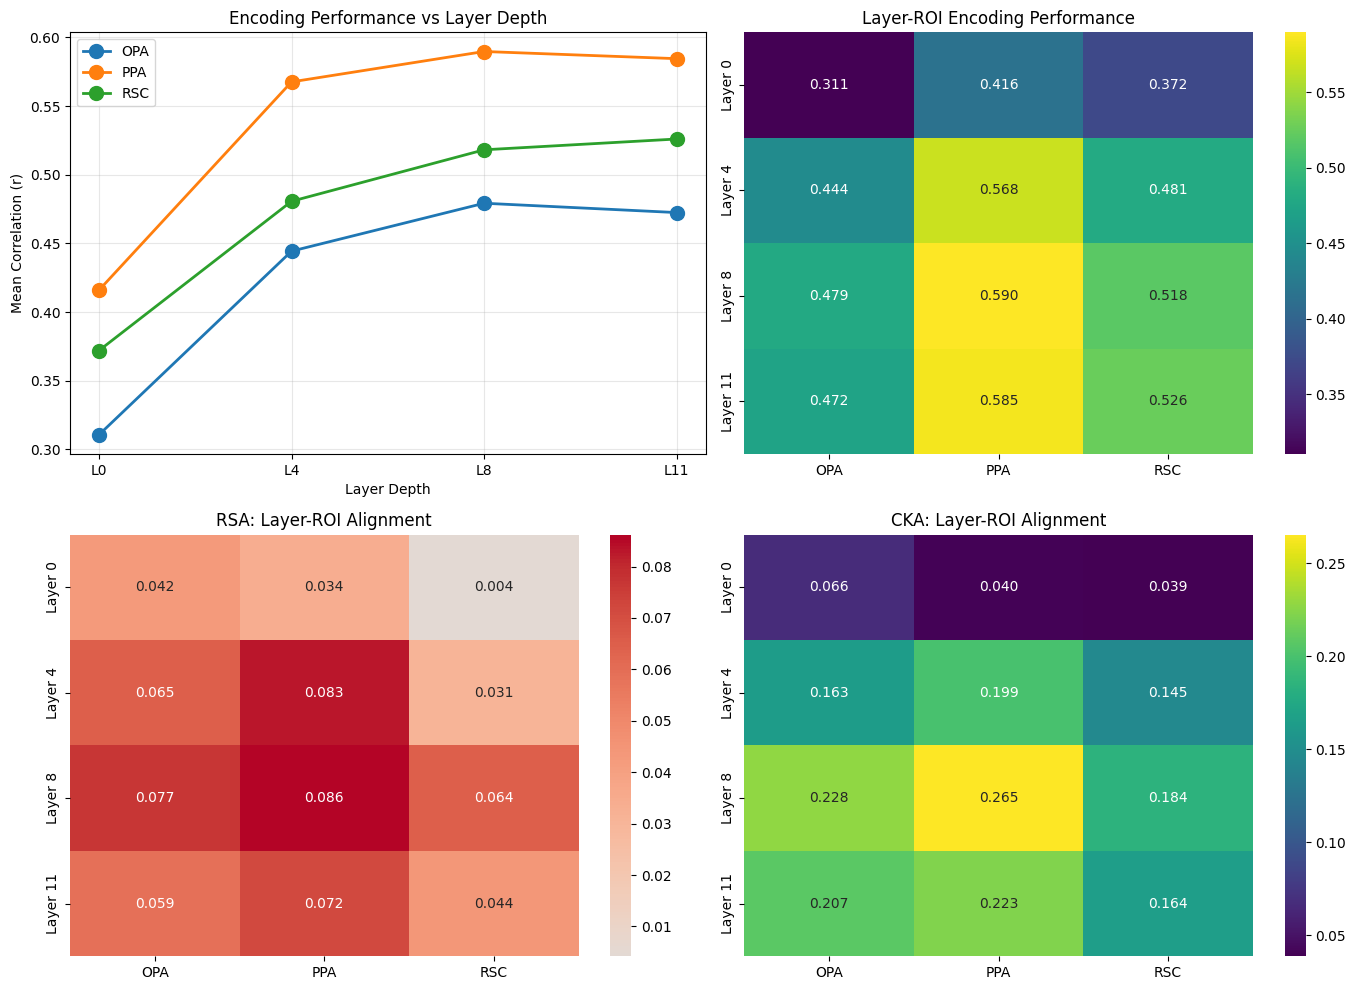

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Line plot: encoding performance vs layer depth
ax = axes[0, 0]
for roi_name in roi_names:
    means = [layerwise_results[layer][roi_name]['mean'] for layer in layer_names]
    ax.plot(range(len(layer_names)), means, 'o-', label=roi_name, linewidth=2, markersize=10)

ax.set_xlabel('Layer Depth')
ax.set_ylabel('Mean Correlation (r)')
ax.set_title('Encoding Performance vs Layer Depth')
ax.set_xticks(range(len(layer_names)))
ax.set_xticklabels([f'L{l}' for l in layer_indices])
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Encoding heatmap
ax = axes[0, 1]
enc_matrix = np.array([[layerwise_results[layer][roi]['mean'] 
                        for roi in roi_names] for layer in layer_names])
sns.heatmap(enc_matrix, annot=True, fmt='.3f', 
            xticklabels=roi_names, yticklabels=[f'Layer {l}' for l in layer_indices],
            cmap='viridis', ax=ax)
ax.set_title('Layer-ROI Encoding Performance')

# 3. RSA heatmap
ax = axes[1, 0]
rsa_matrix = np.array([[rsa_results[layer][roi] for roi in roi_names] for layer in layer_names])
sns.heatmap(rsa_matrix, annot=True, fmt='.3f',
            xticklabels=roi_names, yticklabels=[f'Layer {l}' for l in layer_indices],
            cmap='coolwarm', center=0, ax=ax)
ax.set_title('RSA: Layer-ROI Alignment')

# 4. CKA heatmap
ax = axes[1, 1]
cka_matrix = np.array([[cka_results[layer][roi] for roi in roi_names] for layer in layer_names])
sns.heatmap(cka_matrix, annot=True, fmt='.3f',
            xticklabels=roi_names, yticklabels=[f'Layer {l}' for l in layer_indices],
            cmap='viridis', ax=ax)
ax.set_title('CKA: Layer-ROI Alignment')

plt.tight_layout()
plt.savefig('part3_layerwise_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Find best layer per ROI
print("Best layer per ROI:")
print("="*50)

print("\nBy Encoding Performance:")
for roi in roi_names:
    best_layer = max(layer_names, key=lambda l: layerwise_results[l][roi]['mean'])
    print(f"  {roi}: {best_layer} (r = {layerwise_results[best_layer][roi]['mean']:.4f})")

print("\nBy CKA Alignment:")
for roi in roi_names:
    best_layer = max(layer_names, key=lambda l: cka_results[l][roi])
    print(f"  {roi}: {best_layer} (CKA = {cka_results[best_layer][roi]:.4f})")

Best layer per ROI:

By Encoding Performance:
  OPA: layer_8 (r = 0.4792)
  PPA: layer_8 (r = 0.5897)
  RSC: layer_11 (r = 0.5260)

By CKA Alignment:
  OPA: layer_8 (CKA = 0.2281)
  PPA: layer_8 (CKA = 0.2653)
  RSC: layer_8 (CKA = 0.1840)


## Save Results

In [11]:
results = {
    'layerwise_encoding': {layer: {roi: layerwise_results[layer][roi]['mean'] 
                                   for roi in roi_names} for layer in layer_names},
    'rsa_results': rsa_results,
    'cka_results': cka_results,
    'layer_indices': layer_indices
}

with open('part3_layerwise_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("Results saved to part3_layerwise_results.json")

Results saved to part3_layerwise_results.json


## Discussion

**Hierarchical Hypothesis:**
- Early layers (L0-L3): Edge/texture detection → align with early visual areas (V1-V4)
- Middle layers: Intermediate feature combinations
- Late layers: High-level semantic features → align with category-selective regions

**Expected Results for Place-Selective ROIs:**
- OPA, PPA, RSC are high-level scene processing areas
- Expect better alignment with **later DINOv2 layers**
- PPA encodes scene categories → benefits from late semantic features
- RSC (spatial navigation) → may need mid-to-late layers

**Self-supervised vs Language-supervised:**
- DINOv2 (self-supervised): Learns visual structure without explicit semantics
- CLIP (language-supervised): Has explicit scene/object categories
- For place ROIs, CLIP's scene-category knowledge may provide advantage
- DINOv2's self-supervised features capture visual geometry important for spatial regions

**Why Layer Ordering Matters:**
The cortical visual hierarchy (V1→V2→V4→IT) processes information from simple to complex. If DNN layers truly mirror this hierarchy, early layers should correlate with early visual areas and late layers with high-level areas like PPA.